In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import math
import re
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import date
from statsmodels.stats.proportion import proportions_ztest


[StrataScratch Project Description](https://platform.stratascratch.com/data-projects/market-analysis-dublin)

* **what** guests are searching for in Dublin
* which inquiries hosts **tend to accept** (new manager will try to boost the number and quality of hosts in Dublin to fit the demands from guests)

The goal of this challenge is to **analyze, understand, visualize, and communicate the demand / supply** in the market. (look at the breakdown of start date day of the week, or number of nights, or room type that is searched for, and how many hosts accepted the reservation)

* **what the gaps** are between guest demand and host supply that the new city manager could plug to **increase the number of bookings** in Dublin
* what other data would be useful to have to **deepen the analysis and understanding**

In [146]:
# read data
contacts = pd.read_csv('contacts.tsv', sep = '\t')
searches = pd.read_csv('searches.tsv', sep = '\t')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Searches Dataset Analysis (Demand)

In [196]:
# Drop undated searches for users who eventually provided dates
searches_to_drop = searches[(searches['ds_checkin'].isnull())|(searches['ds_checkout'].isnull())]\
.loc[:,['id_user', 'ds', 'ds_checkin', 'ds_checkout']].reset_index(drop = True)\
.merge(
    searches[(searches['ds_checkin'].notnull())&(searches['ds_checkout'].notnull())]\
    .loc[:,['id_user']].reset_index(drop = True),
    how = 'inner',
    on = 'id_user'
)
searches_to_drop['drop_flag'] = 1

searches_filtered = searches.merge(
    searches_to_drop,
    how = 'left',
    on = ['id_user', 'ds', 'ds_checkin', 'ds_checkout']
)
searches_filtered = searches_filtered[searches_filtered['drop_flag'].isnull()].reset_index(drop = True)
print('{}% of searches filtered (st1)'.format(abs(round((searches_filtered.shape[0]/searches.shape[0] - 1)*100, 2))))

# Filter users with outlying search volume (Top 1%)
n_searches_per_user = searches_filtered.groupby('id_user').count()[['ds']].reset_index()
n_searches_per_user.columns = ['id_user', 'n_searches_per_user']
searches_filtered = searches_filtered.merge(n_searches_per_user, how = 'inner', on = 'id_user')

max_n_searches = n_searches_per_user.n_searches_per_user.quantile(q=0.99)
searches_filtered = searches_filtered[searches_filtered['n_searches_per_user'] <= max_n_searches]\
.reset_index(drop = True)
print('{}% of searches filtered (st2)'.format(abs(round((searches_filtered.shape[0]/searches.shape[0] - 1)*100, 2))))

19.4% of searches filtered (st1)
24.6% of searches filtered (st2)


In [6]:
# For each check-in/out date find Day of Week
def week_day(date_str):
    week_d = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
    return week_d[datetime.strptime(date_str, '%Y-%m-%d').weekday()]

searches_filtered['checkin_day'] = searches_filtered['ds_checkin'].apply(lambda x: week_day(x) if type(x) is str else x)
searches_filtered['checkout_day'] = searches_filtered['ds_checkout'].apply(lambda x: week_day(x) if type(x) is str else x)

# Split number of nights into groupps acording to duration
def staying(p):
    periods = {(1,7):'1-7 nights',(8,14):'8-14 nights',(15,30):'15-30 nights',(31,90):'31-90 nights',(91,):'other'}
    period_value = p
    for k in periods.keys():
        if (len(k) == 2 and p >= k[0] and p <= k[1]) or (len(k) == 1 and p >= k[0]):
            period_value = periods[k]
        elif p == 0:
            period_value = 'other'
        else:
            next
    return period_value

# Fill values if we don`t know check-in/out dates
searches_filtered['staying_period'] = searches_filtered['n_nights'].apply(lambda x: staying(x)).fillna('without check-in/out')

In [7]:
# Get the most popular staying duration
nights_stat = pd.DataFrame(searches_filtered['staying_period'].value_counts())

# Number of searches (after filters)
total_searches = nights_stat['count'].sum()
# Number of searches (after filters and if check-in/out dates were specified)
searches_with_dates = nights_stat['count'].sum() - nights_stat.loc['without check-in/out', 'count']

def create_stat_df(df):
    df['%searches'] = df.apply(lambda x: round(x*100/total_searches, 2))
    df['%searches with check-in/out'] = df['count'].apply(lambda x: round(x*100/searches_with_dates, 2))
    df.columns = ['n_searches', '%searches', '%searches with check-in/out']
    if 'without check-in/out' in df.index:
        df.loc['without check-in/out','%searches with check-in/out'] = None
        df = df.reset_index().sort_values(by='staying_period')
    else:
        df = df.reset_index().sort_values(by='n_nights')
    return df
    
create_stat_df(nights_stat)

,staying_period,n_searches,%searches,%searches with check-in/out
0,1-7 nights,19020,70.58,86.23
3,15-30 nights,896,3.33,4.06
4,31-90 nights,594,2.20,2.69
2,8-14 nights,1289,4.78,5.84
5,other,258,0.96,1.17
1,without check-in/out,4890,18.15,NaN


In [8]:
# For the short duration (1-7 nights) also find number of searches and their share
f_week = pd.DataFrame(
    searches_filtered[searches_filtered['staying_period']=='1-7 nights']['n_nights'].value_counts()
)
create_stat_df(f_week)

,n_nights,n_searches,%searches,%searches with check-in/out
2,1.0,3321,12.32,15.06
0,2.0,4835,17.94,21.92
1,3.0,4712,17.49,21.36
3,4.0,2898,10.75,13.14
4,5.0,1364,5.06,6.18
6,6.0,837,3.11,3.79
5,7.0,1053,3.91,4.77


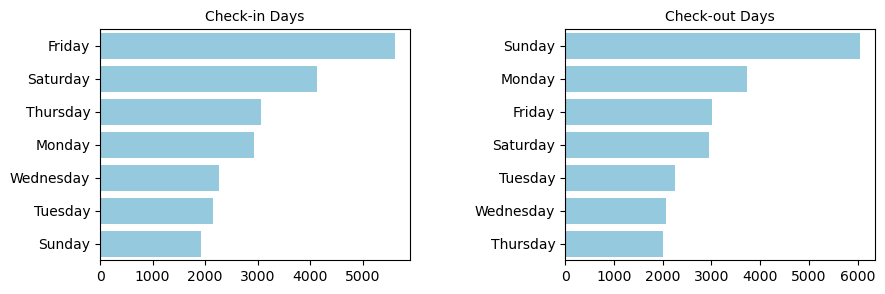

In [9]:
# The most popular Days of Week for check-in and check-out
checkin_df = searches_filtered['checkin_day'].value_counts().reset_index()
checkout_df = searches_filtered['checkout_day'].value_counts().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
fig.subplots_adjust(wspace = 0.5)

sns.barplot(
    data = checkin_df, x = 'count', y = 'checkin_day',
    order=checkin_df.sort_values('count', ascending = False).checkin_day,
    color='skyblue',
    ax=ax[0]
)
ax[0].set_title('Check-in Days', fontsize=10)
ax[0].set(xlabel=None, ylabel=None)

sns.barplot(
    data = checkout_df, x = 'count', y = 'checkout_day',
    order=checkout_df.sort_values('count', ascending = False).checkout_day,
    color='skyblue',
    ax=ax[1]
)
ax[1].set_title('Check-out Days', fontsize=10)
ax[1].set(xlabel=None, ylabel=None)

plt.show()

In [10]:
print('% of bookings when the check-in/out dates were specified by user (duration 1-7 nights)')
display((round(pd.Series(searches_filtered[searches_filtered['staying_period']=='1-7 nights']['checkin_day']+'-'+\
searches_filtered[searches_filtered['staying_period']=='1-7 nights']['checkout_day']).value_counts()*100\
/searches_with_dates, 2)).head(4))

% of bookings when the check-in/out dates were specified by user (duration 1-7 nights)


Friday-Sunday      10.12
Friday-Monday       6.28
Saturday-Sunday     5.05
Thursday-Sunday     4.67
Name: count, dtype: float64

In [12]:
# Number of guest Analysis
# If the min and max number of guests are not the same, provide range "min-max guests"
guest_range = []
for i in range(searches_filtered.shape[0]):
    guest_range_value = None
    
    if searches_filtered['n_guests_min'][i] == searches_filtered['n_guests_max'][i]:
        guest_range_value = '{} guests'.format(searches_filtered['n_guests_min'][i])
    else:
        guest_range_value = '{} guests'.format(
            str(searches_filtered['n_guests_min'][i]) + '-' + str(searches_filtered['n_guests_max'][i]))
    guest_range.append(guest_range_value)
        
searches_filtered['n_guests_range'] = guest_range

In [13]:
# What are the post popular groups of guests:
display(round(searches_filtered['n_guests_range'].value_counts()*100/searches_filtered.shape[0], 2).head(5))

n_guests_range
1 guests      40.26
2 guests      25.64
1-2 guests     8.46
4 guests       5.81
3 guests       5.06
Name: count, dtype: float64

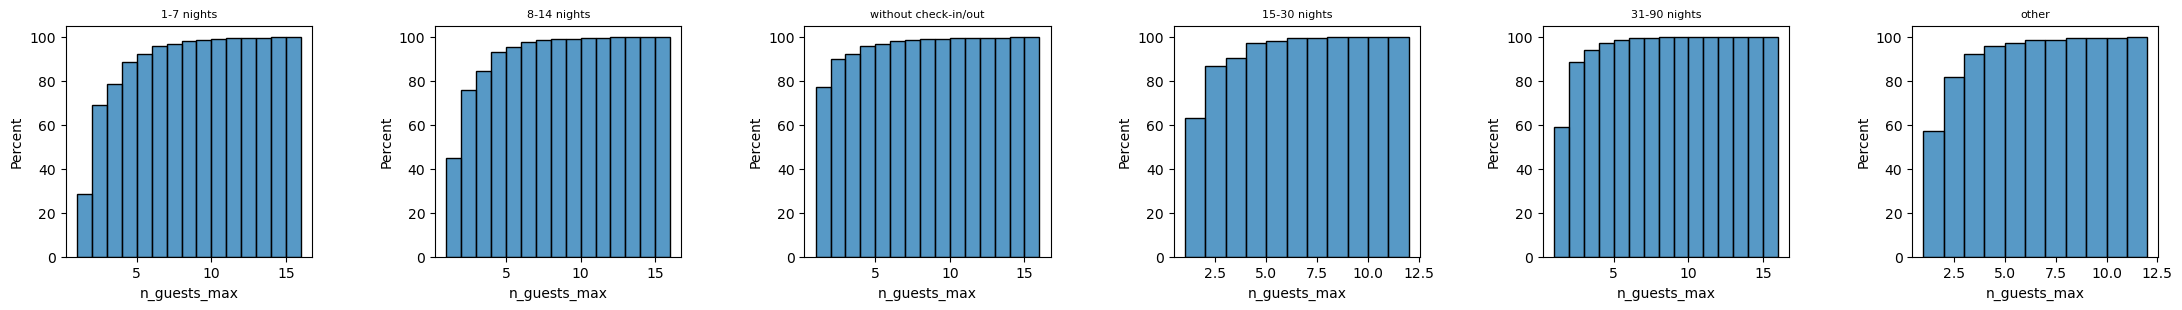

%searches                                               \
staying_period 1-7 nights 15-30 nights 31-90 nights 8-14 nights  other   
n_guests_range                                                           
1 guests            28.56        63.17        59.09       44.92  56.98   
1-2 guests           9.03         6.14         7.07        6.83   4.26   
1-3 guests            NaN          NaN          NaN         NaN    NaN   
1-4 guests            NaN          NaN          NaN         NaN    NaN   
2 guests            31.56        17.19        22.22       23.89  20.54   
3 guests             6.24         2.01         3.37        6.36   6.59   
4 guests             7.11         5.36         2.53        6.28   3.10   

                                     
staying_period without check-in/out  
n_guests_range                       
1 guests                      77.18  
1-2 guests                     7.48  
1-3 guests                     1.43  
1-4 guests                     2.11  
2 guests                       5.34  
3 guests                        NaN  
4 guests                        NaN

In [14]:
# Distribution of Number of guests for each "staying duration" group
unique_staying_periods = searches_filtered['staying_period'].unique()

fig, ax = plt.subplots(1, len(unique_staying_periods), figsize=(27, 3))
fig.subplots_adjust(wspace = 0.5)

top_n_guests = []
for i in range(len(unique_staying_periods)):
    df_i = pd.DataFrame(
        round(
            searches_filtered[searches_filtered['staying_period']==unique_staying_periods[i]]['n_guests_range']\
            .value_counts()*100\
            /searches_filtered[searches_filtered['staying_period'] == unique_staying_periods[i]].shape[0]\
            , 2).head(5)
    )
    df_i.columns = ['%searches']
    df_i['staying_period'] = unique_staying_periods[i]
    top_n_guests.append(df_i.reset_index())
    
    sns.histplot(
        x = searches_filtered[searches_filtered['staying_period'] == unique_staying_periods[i]]['n_guests_max'],
        cumulative=True, stat='percent', ax=ax[i], binwidth=1)
    ax[i].set_title(unique_staying_periods[i], fontsize=8)

plt.show()    
pd.pivot_table(pd.concat(top_n_guests), values=['%searches'], index='n_guests_range', columns = 'staying_period')

### Filters Usage

In [15]:
# Clean filters
def clear_filter(filter_string):
    unique_filter_values = set(filter_string.split(','))
    unique_filter_values.discard('')
    unique_filter_values = list(unique_filter_values)
    unique_filter_values.sort()
    return ",".join(unique_filter_values)

def add_clean_filter(data, field_name):
    data[field_name + '_clean'] = data[field_name].apply(lambda x: clear_filter(x) if type(x) is str else x)
    return

add_clean_filter(searches_filtered, 'filter_room_types')
add_clean_filter(searches_filtered, 'filter_neighborhoods')

In [16]:
# % searches where filters were used
def str_filter_stat(data, filter_field, filter_pretty_name):
    notnull_filter = data[data[filter_field].notnull()].shape[0]
    total_filter = data.shape[0]
    filter_share = round(notnull_filter*100/total_filter, 2)

    top_values = pd.DataFrame(round(data[filter_field].value_counts()*100/notnull_filter, 2))
    top_values.columns = ['Filter Usage (%)']
    print('{}% of searches, where {} filter was used'.format(filter_share, filter_pretty_name))
    return  display(top_values.head(3))


In [17]:
str_filter_stat(searches_filtered, 'filter_room_types_clean', 'room_types')

51.36% of searches, where room_types filter was used


,Filter Usage (%)
filter_room_types_clean,
Entire home/apt,62.51
Private room,16.50
"Entire home/apt,Private room",15.43


In [18]:
city_center_p = round(searches_filtered['filter_neighborhoods_clean'].apply(
    lambda x: 1 if type(x) is str and 'City Centre' in x else 0).sum()*100/(
    searches_filtered[searches_filtered['filter_neighborhoods_clean'].notnull()].shape[0]
), 2)
str_filter_stat(searches_filtered, 'filter_neighborhoods_clean', 'neighborhoods')
print('in {}% of searches where neighborhoods filter were used, users were looking for \
"City Centre" location'.format(city_center_p))

4.43% of searches, where neighborhoods filter was used


,Filter Usage (%)
filter_neighborhoods_clean,
City Centre,57.15
"City Centre,Old City",5.02
"City Centre,Temple Bar",3.60


in 80.75% of searches where neighborhoods filter were used, users were looking for "City Centre" location


2.5% of searches where MIN price filter was really used


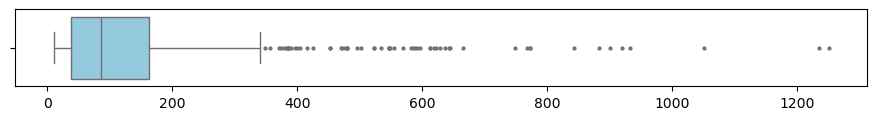

39.01% of searches where MAX price filter was really used


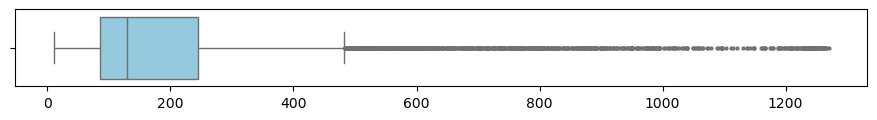

In [19]:
# Price filter
min_price = int(searches_filtered['filter_price_min'].min())
max_price = int(searches_filtered['filter_price_max'].max())

# searches where min_price_filter was really used (the value is different from default = min)
filter_price_min_used = searches_filtered[searches_filtered['filter_price_min'] > min_price].shape[0]
# searches where max_price_filter was really used (the value is different from default = max)
filter_price_max_used = searches_filtered[searches_filtered['filter_price_max'] < max_price].shape[0]

values_min_f = searches_filtered[searches_filtered['filter_price_min'] > min_price]['filter_price_min'].values
values_max_f = searches_filtered[searches_filtered['filter_price_max'] < max_price]['filter_price_max'].values

print('{}% of searches where MIN price filter was really used'.format(
    round(filter_price_min_used*100/searches_filtered.shape[0], 2)))
f, ax = plt.subplots(figsize=(11, 1))
flierprops = dict(markerfacecolor='0.5', markersize=2, linestyle='none')
sns.boxplot(x=values_min_f, flierprops=flierprops, color='skyblue')
plt.show()


print('{}% of searches where MAX price filter was really used'.format(
    round(filter_price_max_used*100/searches_filtered.shape[0], 2)))
f, ax = plt.subplots(figsize=(11, 1))
flierprops = dict(markerfacecolor='0.5', markersize=2, linestyle='none')
sns.boxplot(x=values_max_f, flierprops=flierprops, color='skyblue')
plt.show()

# 📊 Airbnb Market Demand Analysis (Results)

## 🛠 1. Data Pre-filtering & Methodology
* **Incomplete Sessions:** If a user initially left the check-in/out dates blank but later updated the request to include them, the initial observations with empty dates were removed from the dataset.
* **Outlier Removal:** The top **1%** of users (those with an uncharacteristically high volume of requests) were excluded to prevent data skewing.

---

## 📈 2. Booking Duration & Temporal Trends
Among the **82%** of searches where specific dates were provided:

### **Top Stay Durations**
> **86%** of all searches are for short-term stays (1–7 nights).


* **2 Nights**: `22% of Searches`
* **3 Nights**: `21% of Searches`
* **1 Night**: `15% of Searches`
* **4 Nights**: `13% of Searches`

### **Most Popular Date Ranges**
The most frequent searches revolve around the weekend and adjacent days:
* **Fri - Sun** (2 nights): `10.12%`
* **Fri - Mon** (3 nights): `6.28%`
* **Sat - Sun** (1 night): `5.05%`
* **Thu - Sun** (3 nights): `4.67%`

*Note: **18%** of users search without entering any specific dates.*

---

## 👥 3. Guest Composition
The vast majority of demand (**74%**) comes from individuals or couples.

* **1 Guest:** `40.26%`
* **2 Guests:** `25.64%`
* **1-2 Guests:** `8.46%`
* **4 Guests:** `5.81%`
* **3 Guests:** `5.06%`

**💡 Pro Tip:** For stays of **1–7 nights**, the split between 1 and 2 guests is nearly even (**28.56% vs 31.56%**). However, for longer or undefined periods, users tend to default their search to **1 guest**.

---

## 🔍 4. Filter Usage & Preferences

### **🏠 Room Types**
Used in **51.36%** of searches. Demand is heavily skewed toward privacy:
1.  **Entire home/apt:** `62.51%`
2.  **Private room:** `16.50%`
3.  **Combined (Entire home + Private):** `15.43%`

### **📍 Neighborhoods**
Used in only **4.43%** of searches. 
* Of those who use this filter, **81%** specifically select the **City Centre**.

### **💰 Pricing Filters**
* **Min Price:** Rarely used (2.5%).
* **Max Price:** Highly utilized (**39%**).
    * **Median Max Price:** 130 per night.
    * **Absolute Max (Cap):** 500 per night (after outlier removal).

# Contacts Dataset Analysis (Supply)

In [20]:
# Filter contacts, check if contact has a corresponding search
# Add date of a contact
contacts['dc'] = contacts['ts_contact_at'].apply(lambda x: x.split(' ')[0])
# Add first known date of search
contacts_ext = contacts.merge(
    searches_filtered.loc[:,['id_user', 'ds']].groupby('id_user').min().reset_index(),
    how = 'left', left_on = 'id_guest', right_on = 'id_user'
)
# Add flag: True if contact were created after or at the same date as search
contacts_ext['contact_after_search'] = (
    contacts_ext['dc'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d') if type(x) is str else None) -\
    contacts_ext['ds'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d') if type(x) is str else None))\
    .apply(lambda x: x.days) >= 0

print('{}% of contacts without corresponding search'.format(
    round(contacts_ext[contacts_ext['contact_after_search']==False].shape[0]*100/contacts_ext.shape[0], 2)
))

16.86% of contacts without corresponding search


In [21]:
# Analyse current funnel (in users)
total_users = searches_filtered['id_user'].nunique()
users_with_contact = contacts_ext[contacts_ext['contact_after_search']==True]['id_guest'].nunique()
users_with_reply = contacts_ext[
    (contacts_ext['contact_after_search']==True)&(contacts_ext['ts_reply_at'].notnull())
]['id_guest'].nunique()
users_with_accepted_request = contacts_ext[
    (contacts_ext['contact_after_search']==True)&(contacts_ext['ts_accepted_at'].notnull())
]['id_guest'].nunique()
users_with_booking = contacts_ext[
    (contacts_ext['contact_after_search']==True)&(contacts_ext['ts_booking_at'].notnull())
]['id_guest'].nunique()

booking_funnel = pd.DataFrame(pd.Series(
    data =[total_users, users_with_contact, users_with_reply, users_with_accepted_request, users_with_booking],
    index = ['total_users','users_with_contact','users_with_reply',
             'users_with_accepted_request','users_with_booking'],
    name = 'Users Funnel'
))
booking_funnel['CTR%'] = round(booking_funnel['Users Funnel']*100/booking_funnel['Users Funnel'].shift(1), 2)
booking_funnel['CR%'] = round(booking_funnel['Users Funnel']*100/booking_funnel['Users Funnel']['total_users'], 2)
booking_funnel.loc['total_users','CR%'] = None
booking_funnel

,Users Funnel,CTR%,CR%
total_users,18441,NaN,NaN
users_with_contact,2988,16.20,16.20
users_with_reply,2901,97.09,15.73
users_with_accepted_request,2275,78.42,12.34
users_with_booking,1890,83.08,10.25


In [22]:
# AVG acceptance rate
booking_funnel.loc['users_with_accepted_request','Users Funnel']/booking_funnel.loc['users_with_contact','Users Funnel']

np.float64(0.7613788487282463)

In [23]:
# Calculate number of nights users whant to book for each request
contacts_ext['n_nights_requested'] = (
    contacts_ext['ds_checkout'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d').date()) - \
    contacts_ext['ds_checkin'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d').date())
).apply(lambda x: x.days)

# Calculate number of days before check-in
contacts_ext['n_days_before_checkin'] = (
    contacts_ext['ds_checkin'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d').date()) - \
    contacts_ext['ts_contact_at'].apply(lambda x: datetime.strptime(x.split(' ')[0], '%Y-%m-%d').date())
).apply(lambda x: x.days)

In [24]:
# Calculate acceptance rate for each group
n_nights_gr = contacts_ext.groupby(by='n_nights_requested').count().loc[:,['ts_contact_at','ts_accepted_at']]
n_nights_gr.columns = ['n_contacts', 'n_accepted']
n_nights_gr['acceptance_rate'] = n_nights_gr['n_accepted']/n_nights_gr['n_contacts']

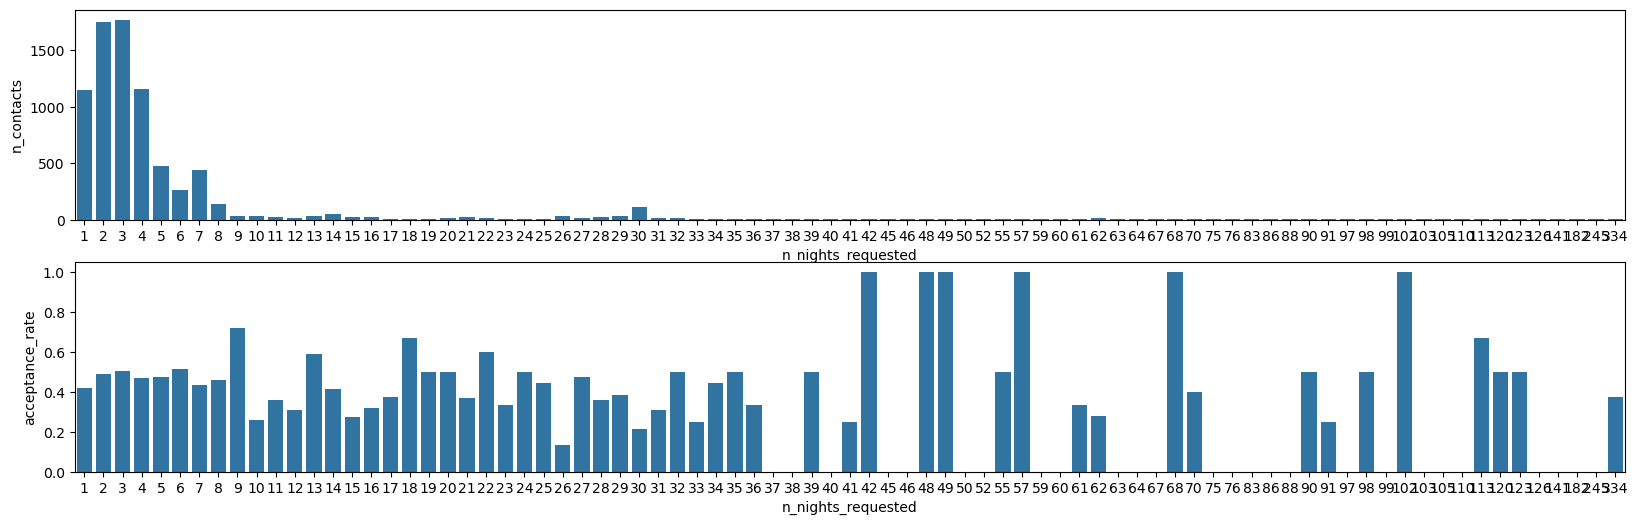

In [25]:
fig, ax = plt.subplots(2, 1, figsize=(20, 6))
sns.barplot(
    x = n_nights_gr.reset_index()['n_nights_requested'], y = n_nights_gr.reset_index()['n_contacts'],
    ax = ax[0]
)
sns.barplot(
    x = n_nights_gr.reset_index()['n_nights_requested'], y = n_nights_gr.reset_index()['acceptance_rate'],
    ax = ax[1]
)
plt.show()

In [26]:
print('{}% contacts with request to book accommodation for 1-7 nights'.format(
    round(n_nights_gr.iloc[0:7,]['n_contacts'].sum()*100/n_nights_gr['n_contacts'].sum(), 2)))

89.52% contacts with request to book accommodation for 1-7 nights


In [27]:
# Compare acceptance rate for most popular duration(nuber of nights requested) (1-7 nights)
def pval_acceptance_rate(data, start_period, end_period, str_param):
    for i in range(start_period, end_period):
        for j in range(i, end_period):
            count = np.array([data.loc[i,'n_accepted'], data.loc[j+1,'n_accepted']])
            nobs = np.array([data.loc[i,'n_contacts'], data.loc[j+1,'n_contacts']])
            stat, pval = proportions_ztest(count, nobs)
            if pval < 0.05:
                print('{} {}(s) request vs {} {}(s) request'.format(i, str_param, j+1, str_param))
                print('pval {0:0.3f}'.format(pval))
            else:
                next
    return

In [28]:
print('Acceptance rates for one-night stays are significantly lower than for longer, \
more popular durations (such as 2+ nights)')
pval_acceptance_rate(n_nights_gr, 1, 7, 'night')

Acceptance rates for one-night stays are significantly lower than for longer, more popular durations (such as 2+ nights)
1 night(s) request vs 2 night(s) request
pval 0.000
1 night(s) request vs 3 night(s) request
pval 0.000
1 night(s) request vs 4 night(s) request
pval 0.016
1 night(s) request vs 5 night(s) request
pval 0.042
1 night(s) request vs 6 night(s) request
pval 0.007
2 night(s) request vs 7 night(s) request
pval 0.043
3 night(s) request vs 7 night(s) request
pval 0.010
6 night(s) request vs 7 night(s) request
pval 0.046


In [29]:
# Acceptance rate for the most popular durations
n_nights_gr.iloc[0:7,:]

,n_contacts,n_accepted,acceptance_rate
n_nights_requested,,,
1,1150,483,0.420000
2,1751,854,0.487721
3,1770,890,0.502825
4,1156,543,0.469723
5,478,227,0.474895
6,260,133,0.511538
7,438,190,0.433790


In [30]:
# How acceptance rate depand on interval between contact date and check-in date
n_days_before_gr = contacts_ext.groupby(by='n_days_before_checkin')\
.count().loc[:,['ts_contact_at','ts_accepted_at']]
n_days_before_gr.columns = ['n_contacts', 'n_accepted']
n_days_before_gr['acceptance_rate'] = n_days_before_gr['n_accepted']/n_days_before_gr['n_contacts']

Users mostly contacted with hosts less than 100 days before checkin


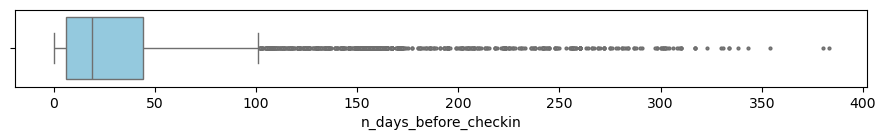

In [32]:
f, ax = plt.subplots(figsize=(11, 1))
flierprops = dict(markerfacecolor='0.5', markersize=2, linestyle='none')
sns.boxplot(x=contacts_ext['n_days_before_checkin'], flierprops=flierprops, color='skyblue')
print('Users mostly contacted with hosts less than 100 days before checkin')
plt.show()

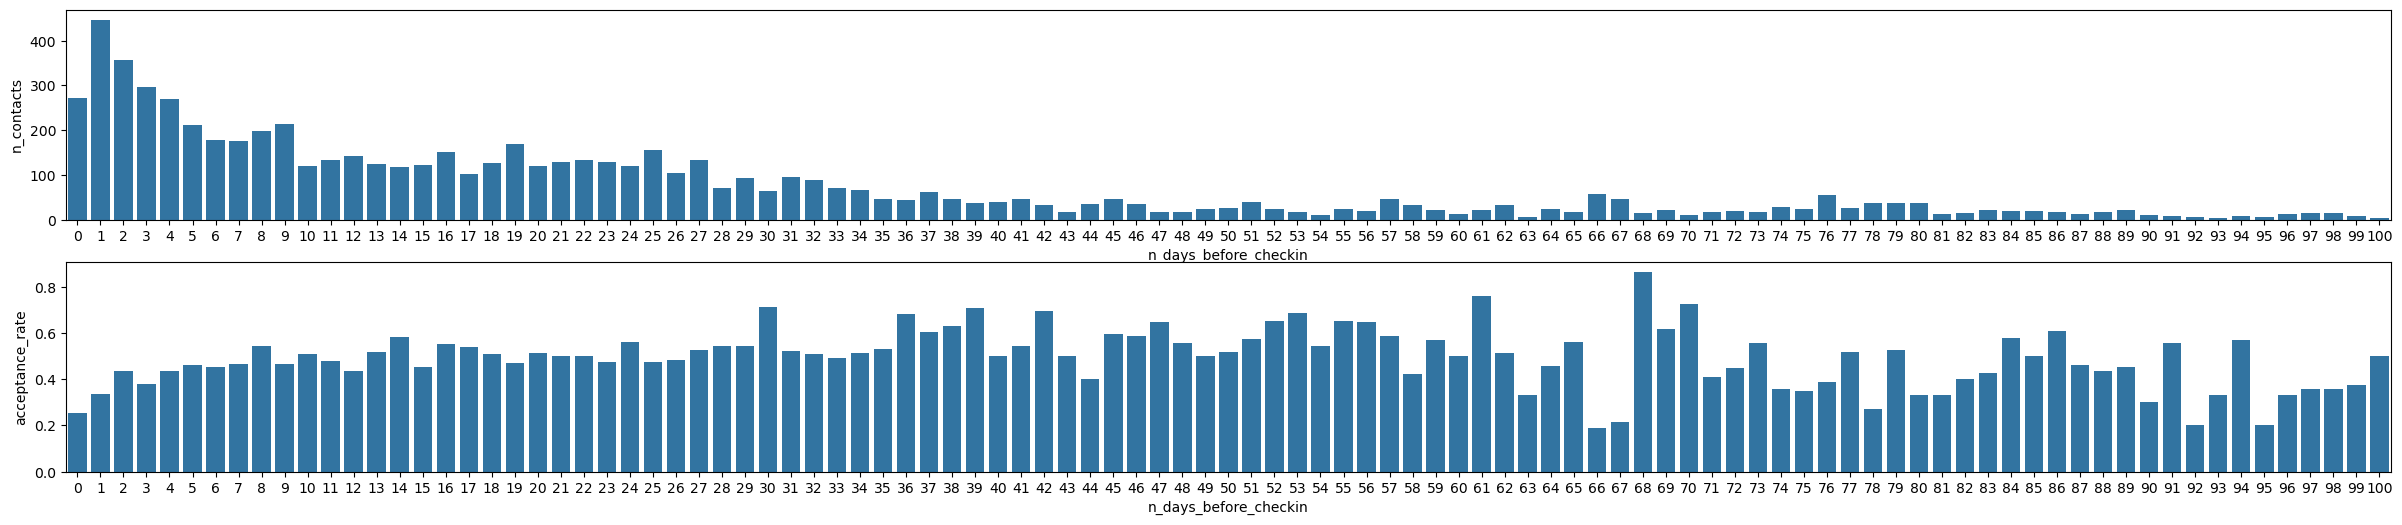

In [33]:
fig, ax = plt.subplots(2, 1, figsize=(30, 6))
sns.barplot(
    x = n_days_before_gr.iloc[0:101,].reset_index()['n_days_before_checkin'],
    y = n_days_before_gr.iloc[0:101,].reset_index()['n_contacts'],
    ax = ax[0]
)
sns.barplot(
    x = n_days_before_gr.iloc[0:101,].reset_index()['n_days_before_checkin'],
    y = n_days_before_gr.iloc[0:101,].reset_index()['acceptance_rate'],
    ax = ax[1]
)
plt.show()

In [34]:
pval_acceptance_rate(n_days_before_gr, 0, 7, 'day')

0 day(s) request vs 1 day(s) request
pval 0.021
0 day(s) request vs 2 day(s) request
pval 0.000
0 day(s) request vs 3 day(s) request
pval 0.001
0 day(s) request vs 4 day(s) request
pval 0.000
0 day(s) request vs 5 day(s) request
pval 0.000
0 day(s) request vs 6 day(s) request
pval 0.000
0 day(s) request vs 7 day(s) request
pval 0.000
1 day(s) request vs 2 day(s) request
pval 0.004
1 day(s) request vs 4 day(s) request
pval 0.008
1 day(s) request vs 5 day(s) request
pval 0.002
1 day(s) request vs 6 day(s) request
pval 0.005
1 day(s) request vs 7 day(s) request
pval 0.002


In [35]:
print('Acceptance rate significantly less if user request came at the same day or day before check-in date')
print('Acceptance rate at the same day – {}%'.format(
    round(n_days_before_gr.iloc[0,]['n_accepted']*100/n_days_before_gr.iloc[0,]['n_contacts'], 2)
))
print('Acceptance rate if request came the day before – {}%'.format(
    round(n_days_before_gr.iloc[1,]['n_accepted']*100/n_days_before_gr.iloc[1,]['n_contacts'], 2)
))
print('Acceptance rate if request came 2-7 days before – {}%'.format(
    round(n_days_before_gr.iloc[2:8,]['n_accepted'].sum()*100/n_days_before_gr.iloc[2:8,]['n_contacts'].sum(), 2)
))

Acceptance rate significantly less if user request came at the same day or day before check-in date
Acceptance rate at the same day – 25.37%
Acceptance rate if request came the day before – 33.56%
Acceptance rate if request came 2-7 days before – 43.35%


In [36]:
# Compare if user request came before 2-7 days before check-in or 8-14 days before check-in
count = np.array([n_days_before_gr.iloc[2:8,]['n_accepted'].sum(), n_days_before_gr.iloc[8:15,]['n_accepted'].sum()])
nobs = np.array([n_days_before_gr.iloc[2:8,]['n_contacts'].sum(), n_days_before_gr.iloc[8:15,]['n_contacts'].sum()])
stat, pval = proportions_ztest(count, nobs)
print('{} accepatance rate if request came 2-7 days before check-in vs \
{} accepatance rate if request came 8-14 days before check-in'.format(
    round(n_days_before_gr.iloc[2:8,]['n_accepted'].sum()*100/n_days_before_gr.iloc[2:8,]['n_contacts'].sum(), 2),
    round(n_days_before_gr.iloc[8:15,]['n_accepted'].sum()*100/n_days_before_gr.iloc[8:15,]['n_contacts'].sum(), 2),
))
print('pval {0:0.3f}'.format(pval))
print('accepatance rate is less if request came less than a week before check-in')

43.35 accepatance rate if request came 2-7 days before check-in vs 50.29 accepatance rate if request came 8-14 days before check-in
pval 0.001
accepatance rate is less if request came less than a week before check-in


In [37]:
# Number of guests vs acceptance rate
n_guests_gr = contacts_ext.groupby(by='n_guests')\
.count().loc[:,['ts_contact_at','ts_accepted_at']]
n_guests_gr.columns = ['n_contacts', 'n_accepted']
n_guests_gr['acceptance_rate'] = n_guests_gr['n_accepted']/n_guests_gr['n_contacts']

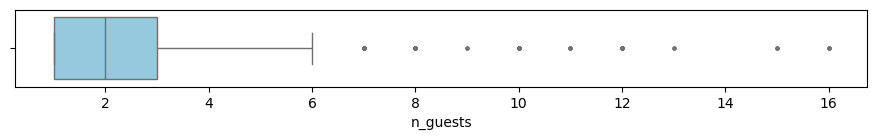

In [38]:
f, ax = plt.subplots(figsize=(11, 1))
flierprops = dict(markerfacecolor='0.5', markersize=2, linestyle='none')
sns.boxplot(x=contacts_ext.n_guests, flierprops=flierprops, color='skyblue')
plt.show()

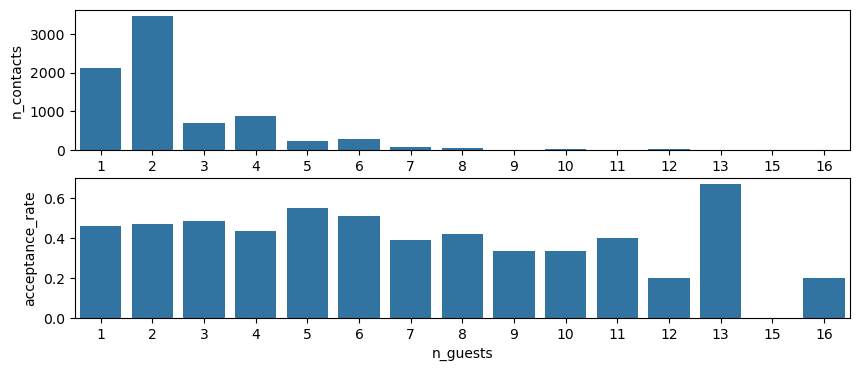

In [39]:
fig, ax = plt.subplots(2, 1, figsize=(10, 4))
sns.barplot(
    x = n_guests_gr.reset_index()['n_guests'], y = n_guests_gr.reset_index()['n_contacts'], ax = ax[0]
)
sns.barplot(
    x = n_guests_gr.reset_index()['n_guests'], y = n_guests_gr.reset_index()['acceptance_rate'], ax = ax[1]
)
plt.show()

In [40]:
pval_acceptance_rate(n_guests_gr, 1, 6, 'guest')

1 guest(s) request vs 5 guest(s) request
pval 0.007
2 guest(s) request vs 5 guest(s) request
pval 0.015
4 guest(s) request vs 5 guest(s) request
pval 0.002
4 guest(s) request vs 6 guest(s) request
pval 0.024


# 📊 Airbnb Market Supply Analysis (Results)

## 🌪 5. Conversion Funnel Analysis
*Note: This funnel only accounts for contacts made strictly after a search was performed.*

| Step | Users | CTR% | CR% |
| :--- | :---: | :---: | :---: |
| **Total Users** | 18,441 | NaN | NaN |
| **Users with Contact** | 2,988 | 16.20% | 16.20% |
| **Users with Reply** | 2,901 | 97.09% | 15.73% |
| **Users with Accepted Request** | 2,275 | 78.42% | 12.34% |
| **Users with Booking** | 1,890 | 83.08% | 10.25% |

**Key Metric:** The average **Acceptance Rate** after contacting a host is **76%**.

---

## 📉 6. Acceptance Rate vs. Stay Duration
While **89.52%** of all booking contacts are for short stays (1–7 nights), hosts are less likely to accept very short trips.

| Nights Requested | Contacts | Accepted | Acceptance Rate |
| :---: | :---: | :---: | :---: |
| **1** | 1,150 | 483 | **42.00%** |
| **2** | 1,751 | 854 | 48.77% |
| **3** | 1,770 | 890 | **50.28%** |
| **4** | 1,156 | 543 | 46.97% |
| **5** | 478 | 227 | 47.49% |
| **6** | 260 | 133 | 51.15% |
| **7** | 438 | 190 | 43.38% |

> **Insight:** 1-night stays have a significantly lower acceptance rate compared to the most popular 2+ night durations.

---

## ⏰ 7. Lead Time & "Last-Minute" Impact
Most users contact hosts less than 100 days before check-in, with a **median lead time of 30 days**.

### **The "Last-Minute" Penalty**
Acceptance rates drop drastically as the check-in date approaches:
* **Same-day request:** 25.37% acceptance
* **1 day before:** 33.56% acceptance
* **2–7 days before:** 43.35% acceptance
* **8–14 days before:** 50.29% acceptance

**Statistical Significance:** There is a confirmed drop in acceptance if the request comes less than a week before check-in ($p$-value = 0.001). 

---

## 👥 8. Group Size Impact
While searches for small groups are the most frequent (as seen in the previous section), the **number of guests does not significantly impact the Acceptance Rate**. Hosts appear indifferent to group size within the standard capacity limits.

# Gaps Analysis

# 🚀 Executive Recommendation: Supply-Demand Gap Optimization

> **Core Finding:** Neither search volume nor guest count are the primary bottlenecks for conversion. The friction lies in a **structural mismatch** between user demand and available, "bookable" inventory.

---

### 📦 1. The "High-Demand" Inventory Profile
To close the market gap, we must aggressively onboard and optimize listings that fit the following criteria:

* **Duration:** Short-stay friendly (**1–4 nights**).
* **Timing:** High availability for **Weekends** (Fri–Sun).
* **Capacity:** Optimized for small groups (**1–2 guests**).
* **Pricing:** Anchored at a **130/night median**, with a ceiling of **500**.

---

### ⚙️ 2. Strategic Growth Levers

#### **📍 Targeted Acquisition**
Focus on **City Centre** inventory. While neighborhood filters are used selectively, **81%** of those location-specific searches target this specific zone.

#### **⚡ Friction Reduction**
Address the critically low acceptance rates (**25–43%**) for last-minute and 1-night stays. 
* **Action:** Promote **Instant Book** features to hosts to bypass manual approval delays.

---

### 🎯 Conclusion
Conversion will scale by increasing the **density** of central, affordable, short-stay units, rather than simply increasing total search traffic. Volume exists; the goal is now **alignment**.